In [13]:
import numpy as np

from src import Model

consumer_domain = np.array([[0, 10]])
resource_domain = np.array([[0, 1]])
mutation_rate = 50.0

EjemploPerthame = Model(consumer_domain, resource_domain, mutation_rate)


def constante_en_intervalo(
    x: np.ndarray, const: float, a: float, b: float,
) -> np.ndarray:
    return const * ((a <= x) & (x <= b))


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    return np.full_like(z, const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    norm = np.abs(x - y) ** 2
    exp = np.exp(-norm / (2 * sigma_K**2))
    return exp / (sigma_K + np.sqrt(2 * np.pi))


def supply_rate_gaussiano(y: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    exp = np.exp(-(y**2) / (2 * sigma_in**2))
    return M_in * exp / (sigma_in + np.sqrt(2 * np.pi))


EjemploPerthame.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=1.0)
)
EjemploPerthame.set_consumer_growth_rate(lambda x: funcion_constante(x, const=30.8))
EjemploPerthame.set_consumer_decay(lambda x: funcion_constante(x, const=0.1))
EjemploPerthame.set_resource_supply_rate(
    lambda y: supply_rate_gaussiano(y, sigma_in=10.4, M_in=12.0)
)
EjemploPerthame.set_resource_decay(lambda y: funcion_constante(y, const=1))
EjemploPerthame.set_initial_data(
    initial_consumer_distribution=lambda x: constante_en_intervalo(x, 40.0, 4, 6),
    initial_resource_distribution=lambda y: constante_en_intervalo(y, 15.0, 4, 6),
)

In [14]:
T = 10

EjemploPerthame.solve_by_finite_differences(
    T=T,
    n_t=200*T,
    n_x=1000,
    n_y=1000,
    border_type="neumann",
)

In [15]:
EjemploPerthame.consumer_distribution

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.01322077, 0.01322341, 0.01323136, ..., 0.01323136, 0.01322341,
        0.01322077],
       [0.06555562, 0.06556611, 0.06559756, ..., 0.06559232, 0.06556087,
        0.06555038],
       ...,
       [3.5674544 , 3.56745402, 3.56745288, ..., 3.49646099, 3.49646072,
        3.49646064],
       [3.56614542, 3.56614504, 3.5661439 , ..., 3.49515251, 3.49515225,
        3.49515216],
       [3.5648371 , 3.56483672, 3.56483558, ..., 3.49384469, 3.49384443,
        3.49384434]], shape=(2000, 1000))

In [16]:
EjemploPerthame.resource_distribution

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.0046511 , 0.0046511 , 0.0046511 , ..., 0.00462973, 0.00462969,
        0.00462965],
       [0.00920484, 0.00920472, 0.00920459, ..., 0.00887228, 0.00887165,
        0.00887101],
       ...,
       [0.02298906, 0.02297129, 0.02295355, ..., 0.01380581, 0.01380182,
        0.01379782],
       [0.02299729, 0.02297951, 0.02296176, ..., 0.01381081, 0.01380681,
        0.01380282],
       [0.02300552, 0.02298774, 0.02296998, ..., 0.01381581, 0.01381181,
        0.01380782]], shape=(2000, 1000))

In [17]:
EjemploPerthame.consumer_quantity.shape

(2000,)

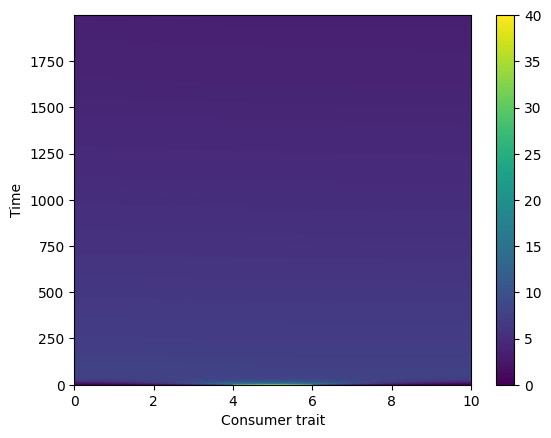

In [18]:
EjemploPerthame.plot.solution_over_time(
    solution="consumer-density",
    # color="red",
    #linestyle="--",
    #linewidth=3,
    #marker="o",
)